In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')
df.head(5)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 4.5 MB


In [4]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: str

In [5]:
# Check for duplicate entries
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


## Data Exploration Summar:
### 1. No duplicate
### 2. Drop Overview, Poster, Language
### 3. Caste release date to date type and keep only YEAR
### 4. Genre column has ", " separated values need to clean that 

In [7]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)

datetime64[us]


In [8]:
# Dropping the month and date, keeping back year
df['Release_Date'] = df['Release_Date'].dt.year

In [9]:
cols = ['Overview', 'Original_Language', 'Poster_Url']
df.drop(cols, axis=1, inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='str')

In [10]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [11]:
def categorize_columns(df, col, labels):
    edges = [df[col].describe()['min'], 
             df[col].describe()['25%'], 
             df[col].describe()['50%'], 
             df[col].describe()['75%'],
             df[col].describe()['max']]
    df[col] = pd.cut(df[col], edges, labels = labels, duplicates = 'drop')
    return df

In [12]:
labels = ['not_popular', 'below_avg', 'avg', 'popular']

In [13]:
categorize_columns(df, 'Vote_Average', labels)

df['Vote_Average'].unique()

['popular', 'below_avg', 'avg', 'not_popular', NaN]
Categories (4, str): ['not_popular' < 'below_avg' < 'avg' < 'popular']

In [14]:
df.head(4)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"


In [15]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
avg            2412
below_avg      2398
Name: count, dtype: int64

In [16]:
df.dropna(inplace=True)

df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [17]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,avg,"Action, Adventure, Thriller, War"


### We will split the genres into list, written one after another

In [18]:
df['Genre'] = df['Genre'].str.split(', ')

In [19]:
df = df.explode('Genre').reset_index(drop = True)
df.head(10)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery
5,2022,The Batman,3827.658,1151,popular,Thriller
6,2022,No Exit,2618.087,122,below_avg,Thriller
7,2021,Encanto,2402.201,5076,popular,Animation
8,2021,Encanto,2402.201,5076,popular,Comedy
9,2021,Encanto,2402.201,5076,popular,Family


In [20]:
df.groupby('Genre').count()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average
Genre,,,,,
Action,2652,2652,2652,2652,2652
Adventure,1829,1829,1829,1829,1829
Animation,1426,1426,1426,1426,1426
Comedy,3006,3006,3006,3006,3006
Crime,1235,1235,1235,1235,1235
Documentary,203,203,203,203,203
Drama,3715,3715,3715,3715,3715
Family,1405,1405,1405,1405,1405
Fantasy,1295,1295,1295,1295,1295


In [21]:
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=str)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  str     
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), str(1)
memory usage: 1.2 MB


# Data Visualisation

In [23]:
sns.set_style('whitegrid')

## 1. What's the most frequent Genre of movies released on Netflix?

In [24]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

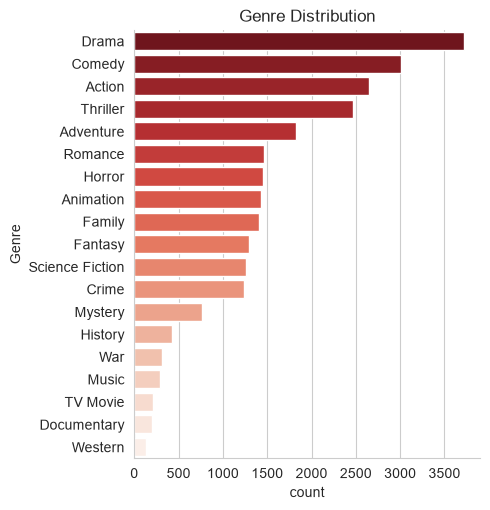

In [25]:
sns.catplot(y = 'Genre', data=df, kind='count', order=df['Genre'].value_counts().index, palette='Reds_r')
plt.title("Genre Distribution")
plt.savefig('Genre-Distribution')
plt.show()

## 2. Which has the highest votes in vote avg column?

In [26]:
df.head(4)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime


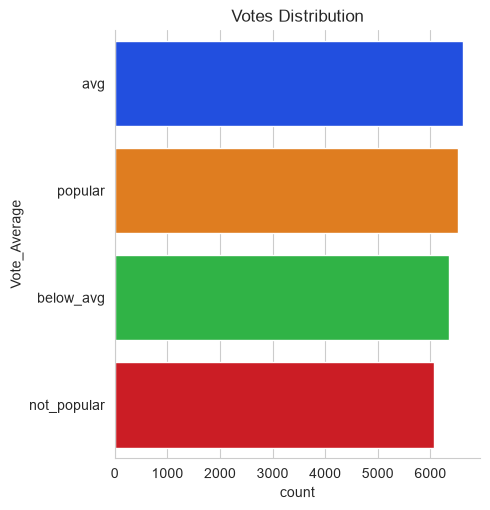

In [27]:
sns.catplot(y = 'Vote_Average', data=df, kind='count', order=df['Vote_Average'].value_counts().index, palette='bright')
plt.title("Votes Distribution")
plt.savefig("Votes-Distribution-by-Popularity")
plt.show()

## 3. Which movie got highest popularity? what is it's Genre?

In [28]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [29]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


In [30]:
print("The Most Popular movie is: Spiderman: No Way Home, It's Genre is Action, Adventure, Science Fiction")

The Most Popular movie is: Spiderman: No Way Home, It's Genre is Action, Adventure, Science Fiction


## 3. Which movie got lowest popularity? what is it's Genre?

In [31]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,avg,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,avg,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,avg,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


In [32]:
print("The Least Popular movie is: The United States vs. Billie Holiday, It's Genre is Music, Drama, History")

The Least Popular movie is: The United States vs. Billie Holiday, It's Genre is Music, Drama, History


## 4. Which year has the Most Filmed Movies?

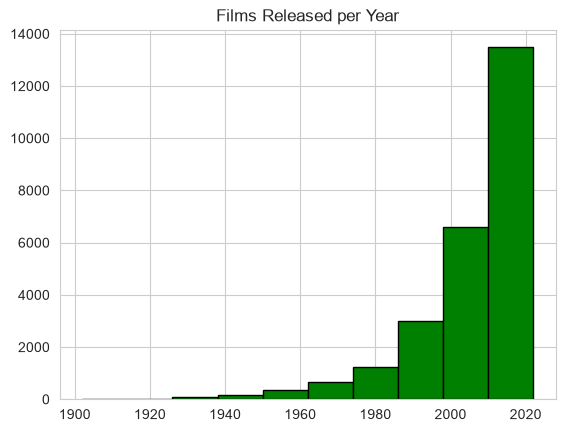

In [33]:
df['Release_Date'].hist(color='green', edgecolor='black')

plt.title("Films Released per Year")
plt.savefig('Film-Released-per-Year')
plt.show()

# Conclusion:
## Q1. What is the most frequent Genre in the Dataset?
## Ans: Drama Genre is the most frequent Genre in this dataset, appeard more than 14% of the times among other 19 genres.

## Q2. Which has the highest votes in vote avg column?
## Ans: We have 25.5% of our datset with popular vote (6520 rows). Darama again gets the highest popularity.

## Q3. Which movie got highest popularity? what is it's Genre?
## Ans: Spider-Man: No Way Home got the highest popularity. It has genres in Action, Adventure, Science-fiction.

## Q4. Which movie got lowest popularity? what is it's Genre?
## Ans: The United States vs. Billie Holiday has the lowest popularity. It's Genre is Music, Drama, History.

## Q5. Which year has the Most Filmed Movies?
## Ans: Year 2020 has the Most Filmed Movie.

## Thank You.
## Soumyadeep Das.